In [5]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

Уровень значимости везде = 0.05

In [6]:
df = pd.read_csv("exams_dataset.csv")
df["mean"] = df[["math score", "reading score", "writing score"]].mean(axis=1)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,mean
0,female,group B,high school,standard,none,67,91,84,80.666667
1,female,group D,some college,standard,none,63,63,67,64.333333
2,female,group A,associate's degree,standard,completed,73,83,85,80.333333
3,female,group C,associate's degree,standard,none,85,98,95,92.666667
4,male,group B,bachelor's degree,standard,none,75,57,63,65.000000


#### Задание 1. Тест на принадлежность к закону распределения

In [7]:
mu = df["mean"].mean()
sigma = df["mean"].std()
print(mu, sigma)

67.468 15.157919260045945


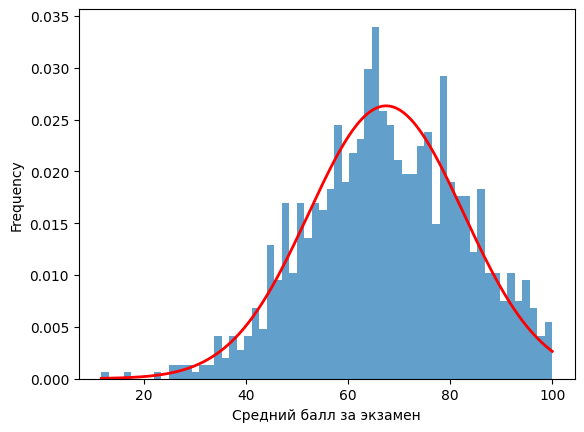

In [8]:
ax = df["mean"].plot(kind="hist", bins=60, density=True, alpha=0.7)
x = np.linspace(df["mean"].min(), df["mean"].max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color='red', lw=2)
ax.set_xlabel("Средний балл за экзамен")
plt.show()

$$
    H_0: F_n(x) \sim N(67.486, 15.157) \\
    H_1: F_n  \not \sim N(67.486, 15.157)
$$

In [9]:
def my_norm_ks_montecarlo(data, mu, sigma):
    sorted_data = np.sort(data)
    n = len(data)
    e = np.arange(1, n+1) / n
    cdf = stats.norm.cdf(sorted_data, mu, sigma)
    d_stat = np.max(np.abs(e - cdf))
    count = 0

    for i in range(100000):
        correct_data = np.random.normal(mu, sigma, n)
        correct_sorted = np.sort(correct_data)
        correct_e = np.arange(1, n+1) / n
        correct_cdf = stats.norm.cdf(correct_sorted, mu, sigma)
        d_stat1 = np.max(np.abs(correct_e - correct_cdf))
        if d_stat1 >= d_stat:
            count += 1

    p_value = count / 100000
    return d_stat, p_value

In [10]:
def my_norm_ks_theorem(data, mu, sigma):
    sorted_data = np.sort(data)
    n = len(data)
    e = np.arange(1, n+1) / n
    cdf = stats.norm.cdf(sorted_data, mu, sigma)
    d_stat = np.max(np.abs(e - cdf))
    
    x = d_stat * np.sqrt(n)
    K_x = 1 - 2 * np.sum([(-1)**(j-1) * np.exp(-2 * j**2 * x**2) for j in range(1, 300)])
    p_value = 1 - K_x
    
    return d_stat, p_value

In [11]:
_, p_value = my_norm_ks_montecarlo(df['mean'], df['mean'].mean(), df['mean'].std())
print(f"Наше p-value (Монте Карло)= {p_value:.4f}")
_, p_value_theorem = my_norm_ks_theorem(df['mean'], df['mean'].mean(), df['mean'].std())
print(f"Наше p-value (функция Колмогорова) = {p_value_theorem:.4f}")

Наше p-value (Монте Карло)= 0.3668
Наше p-value (функция Колмогорова) = 0.3947


In [12]:
d, ks_p = stats.kstest(df["mean"], 'norm', args=(mu, sigma))
print(f"p-value = {ks_p:.4f}")

p-value = 0.3457


p_value больше 0.05, а значит, у нас недостаточно оснований отвергнуть гипотезу о том, что данные распределены нормально (с матожиданием ~ 67.468 и дисперсией ~ 15.157).


Попробуем более подходящий вариант, ведь на практике мы не знаем, какие матожидание и дисперсия у распределения, с которым мы сравниваем, даже если оно нормально. Именно поэтому рассмотрим модифицированную версию теста Колмогорова-Смирнова.

In [16]:
from statsmodels.stats.diagnostic import lilliefors
_, p_value = lilliefors(df['mean'])
print(f"Модифицированный ks-тест (тест Лиллиефорса): p-value = {p_value:.2f}")

Модифицированный ks-тест (тест Лиллиефорса): p-value = 0.05


p_value = 0.05, поэтому мы всё таки отвергаем гипотезу H_0 о том, что данные распределены нормально

#### Задание 2. Проверить, что распределение балла по математике и чтению одинаково

$$
H_0: df\_math \sim df\_reading \\

H_1: df\_math \not \sim df\_reading
$$

In [34]:
df_math = df['math score']
df_reading = df['reading score']

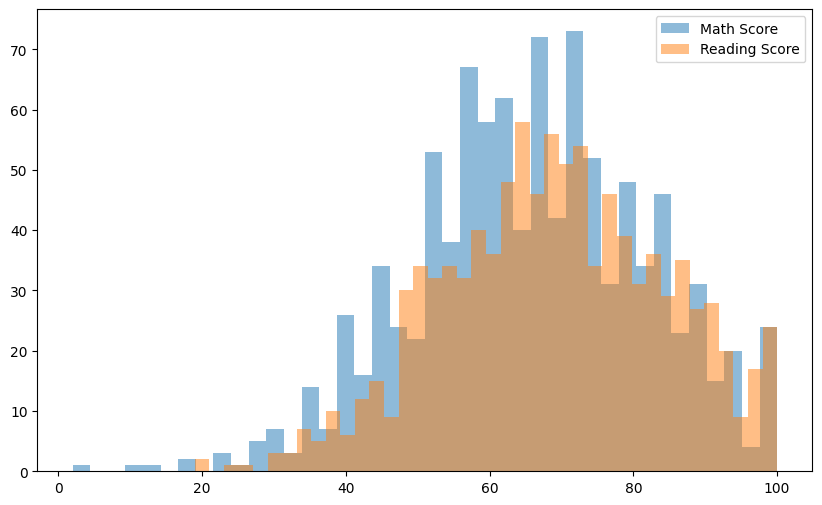

In [35]:
plt.figure(figsize=(10, 6))
plt.hist(df_math, bins=40, alpha=0.5, label='Math Score')
plt.hist(df_reading, bins=40, alpha=0.5, label='Reading Score')
plt.legend()
plt.show()

Для начала проверим независимость выборок:

$$
H_0: \rho = 0 \\

H_1: \rho \neq 0
$$

In [36]:
import numpy as np
import scipy.special
from scipy.stats import rankdata

def spearman_correlation(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    
    n = len(x)
    
    rank_x = rankdata(x, method='average')
    rank_y = rankdata(y, method='average')
    
    mean_x = np.mean(rank_x)
    mean_y = np.mean(rank_y)
    
    cov = np.sum((rank_x - mean_x) * (rank_y - mean_y))
    std_x = np.sqrt(np.sum((rank_x - mean_x) ** 2))
    std_y = np.sqrt(np.sum((rank_y - mean_y) ** 2))
    
    rho = cov / (std_x * std_y)
    
    return rho
   

def spearman_test(x, y):
    rho = spearman_correlation(x, y)
    n = len(x)
    
    z = rho * np.sqrt(n - 1)
    p_val = min(1.0, 2 * min(
        stats.norm(0, 1).cdf(z),
        stats.norm(0, 1).cdf(-z)
    ))
    
    return p_val

print("p_value на Критерии Спирмена:", "{:.10f}".format(float(spearman_test(df_math, df_reading))))

p_value на Критерии Спирмена: 0.0000000000


Значит между выборками есть связь и использовать тесты для независимых выборок нельзя, тогда используем критерий знаков:

$$
H_0: Med(df\_math - df\_reading) = 0 \\

H_1: Med(df\_math - df\_reading) \neq 0
$$

In [37]:
def sign_test(x, y):
    differences = x - y
    nonzero_diffs = differences[differences != 0]
    
    if len(nonzero_diffs) == 0:
        return 0, 1.0  # Все разности нулевые
    
    n_pos = np.sum(nonzero_diffs > 0)
    n_total = len(nonzero_diffs)
    
    p_value = 2 * min(
        stats.binom.cdf(n_pos, n_total, 0.5),
        stats.binom.sf(n_pos - 1, n_total, 0.5)
    )
    
    return p_value

print("p_value на Критерии Знаков:", "{:.10f}".format(float(sign_test(df_math, df_reading))))

p_value на Критерии Знаков: 0.0000000000


p_value < 0.05, а значит, мы отвергаем нулевую гипотезу о том, что выборки однородны (а то есть то, что распределение баллов по математике и чтению одинаковое)

В качетсве второго теста применим тест Уилкоксона. 

In [38]:
_, p_value = stats.wilcoxon(df_math, df_reading, 
                                 alternative='two-sided',
                                 zero_method='wilcox',
                                 correction=False) 
print("p_value на тесте Уилкоксона:", "{:.10f}".format(float(p_value)))

p_value на тесте Уилкоксона: 0.0000000000


А значит оценки не принадлежат одному распределению.

#### Задание 3. Сравнение результатов у тех, кто прослушал курсы, с непрослушившими

In [29]:
df_course = df[df["test preparation course"] == "completed"]
df_no_course = df[df["test preparation course"] == "none"]

Применим тест Уэлча (похож на т-тест, но доспускает неравные дисперсии)

$$
H_0: E(df\_course["mean"]) - E(df\_no\_course["mean")]) \leq 0\\
H_1: E(df\_course["mean"]) - E(df\_no\_course["mean"]) \gt 0
$$

In [30]:
def my_whelch(n, m):
    n = np.array(n)
    m = np.array(m)
    mean_m = np.mean(m)
    mean_n = np.mean(n)
    var_m = np.var(m, ddof=1)
    var_n = np.var(n, ddof=1)
    se = np.sqrt(var_n/len(n) + var_m/len(m))
    t_value = (mean_n - mean_m) / se
    df = (var_n/len(n) + var_m/len(m))**2 / ((var_n/len(n))**2 / (len(n) - 1) + (var_m/len(m))**2 / (len(m) - 1))
    p_value = 1 - t.cdf(t_value, df=df)
    return t_value, p_value

In [31]:
_, p_value = my_whelch(df_course["mean"], df_no_course["mean"])
print("p_value на нашем тесте Уэлча:", "{:.10f}".format(float(p_value)))

p_value на нашем тесте Уэлча: 0.0000000000


p_value < 0.05, значит, мы отвергаем нулевую гипотезу и считаем, что эффект от курсов есть (в положительную сторону).

Теперь сравним результаты по-другому. Проверим есть ли корреляция между тем проходил студент курс или нет и его баллами за тесты. И сделаем это с помощью теста спирмена.

$$
H_0: \rho \le 0 \\

H_1: \rho > 0
$$

In [42]:
_, p_value = stats.spearmanr(df["test preparation course"].map(lambda x : 1 if x == "completed" else 0), df["mean"], alternative='greater')
print(f"p-value на критерии Спирмена: {p_value:.4f}")

p-value на критерии Спирмена: 0.0000


Значит, те кто прошли курс, получили большие баллы чем те, кто курс не проходил